In [3]:
import pandas as pd
import numpy as np
import scipy.stats as ss

import lightfm
import lightfm.data as ld
import lightfm.evaluation as lv

import glob
import tqdm
import json
import optuna

import tensorboardX as tb

import matplotlib.pyplot as pl
import seaborn as sns

np.random.seed(31337)

In [4]:
DATA_DIR = "/Users/n.anokhin/Desktop/"

In [5]:
data = pd.concat([
    pd.read_json(data_path, lines=True) 
    for data_path 
    in glob.glob(DATA_DIR + "/data/*/data.json")
])
data["rnd"] = np.random.random(len(data))

data.head(5)

,message,timestamp,user,track,time,latency,recommendation,experiments,rnd
0,next,2025-08-31 19:29:16.536,1160,1023,0.75,0.002898,3423.0,{'AA': 'C'},0.721852
1,next,2025-08-31 19:29:16.589,5320,12144,0.05,0.000892,1047.0,{'AA': 'T1'},0.966441
2,next,2025-08-31 19:29:16.622,6986,3228,0.07,0.000562,5468.0,{'AA': 'C'},0.289049
3,next,2025-08-31 19:29:16.654,7359,14109,0.25,0.001194,12943.0,{'AA': 'T1'},0.171346
4,next,2025-08-31 19:29:16.673,7359,5658,0.16,0.000533,495.0,{'AA': 'T1'},0.371618


In [7]:
positives = data[data["time"] > 0.7].copy()
positives["test"] = np.random.random(len(positives)) >= 0.7
positives.drop_duplicates(["user", "track"], inplace=True)

In [8]:
user_counts = positives[~positives["test"]].groupby("user").size()
users = set(user_counts[user_counts >= 5].index.values)

In [9]:
track_counts = positives[~positives["test"]].groupby("track").size()
tracks = set(track_counts[track_counts >= 5].index.values)

In [10]:
len(users), len(tracks)

(9756, 13859)

## Train LightFM

In [11]:
train_data = positives[~positives["test"] & positives["user"].isin(users) & positives["track"].isin(tracks)]
test_data = positives[positives["test"] & positives["user"].isin(users) & positives["track"].isin(tracks)]

len(train_data), len(test_data)

(197723, 81468)

In [12]:
dataset = ld.Dataset()
dataset.fit(users, tracks)

In [13]:
train_interactions, _ = dataset.build_interactions(train_data[["user", "track"]].itertuples(index=False, name=None))
test_interactions, _ = dataset.build_interactions(test_data[["user", "track"]].itertuples(index=False, name=None))

In [26]:
def fit_model(
    epochs=1, 
    at=10,
    loss="warp",
    no_components=30,
    learning_rate=0.01, 
    max_sampled=10,
    user_alpha=0.0, 
    item_alpha=0.0, 
    threads=30, 
    verbose=False,
    patience=3,
    epsilon=1e-6,
):
    model = lightfm.LightFM(
        no_components=no_components,
        loss=loss,
        learning_rate=learning_rate,
        max_sampled=max_sampled,
        user_alpha=user_alpha,
        item_alpha=item_alpha,
    )

    precisions_at = []
    
    for epoch in range(epochs):
        model = model.fit_partial(train_interactions, num_threads=threads)
        
        precision_at = lv.precision_at_k(model, test_interactions, train_interactions=train_interactions, k=at, num_threads=threads)
        
        if verbose:
            print(f"{epoch}:\t{np.mean(precision_at)} +/- {ss.sem(precision_at) * 1.96}")
            
        precisions_at.append(np.mean(precision_at))
            
        if epoch > patience and all([precisions_at[-j] - precisions_at[-patience-1] < epsilon for j in range(1, patience + 1)]):
            if verbose:
                print("Early stopiing!")
            break
        
    else:
        if verbose:
            print("No early stopiing happened: increase epochs maybe?")
        
    return model, precisions_at


def objective(trial):
    loss = trial.suggest_categorical("loss", ["warp", "bpr"])
    no_components = trial.suggest_categorical("no_components", [10, 30, 50])
    learning_rate = trial.suggest_categorical("learning_rate", [0.0001, 0.001, 0.01])
    max_sampled = trial.suggest_categorical("max_sampled", [10, 20, 50, 100])
    user_alpha = trial.suggest_categorical("user_alpha", [0.0, 0.0001])
    item_alpha = trial.suggest_categorical("item_alpha", [0.0, 0.0001])
    
    model, precisions_at = fit_model(
        epochs=10, 
        at=10,
        loss=loss,
        no_components=no_components, 
        learning_rate=learning_rate, 
        max_sampled=max_sampled, 
        user_alpha=user_alpha, 
        item_alpha=item_alpha,
    )
    
    return precisions_at[-1]

In [31]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)
best_params = study.best_params

[I 2025-09-01 10:14:02,491] A new study created in memory with name: no-name-d1d02860-5e44-4b9e-82c7-d857f5779a17
[I 2025-09-01 10:14:46,662] Trial 0 finished with value: 0.016240648925304413 and parameters: {'loss': 'warp', 'no_components': 50, 'learning_rate': 0.01, 'max_sampled': 10, 'user_alpha': 0.0001, 'item_alpha': 0.0}. Best is trial 0 with value: 0.016240648925304413.
[I 2025-09-01 10:15:21,484] Trial 1 finished with value: 0.0010390690295025706 and parameters: {'loss': 'bpr', 'no_components': 30, 'learning_rate': 0.001, 'max_sampled': 20, 'user_alpha': 0.0, 'item_alpha': 0.0001}. Best is trial 0 with value: 0.016240648925304413.
[I 2025-09-01 10:15:54,500] Trial 2 finished with value: 0.005101828370243311 and parameters: {'loss': 'warp', 'no_components': 30, 'learning_rate': 0.001, 'max_sampled': 10, 'user_alpha': 0.0001, 'item_alpha': 0.0}. Best is trial 0 with value: 0.016240648925304413.
[I 2025-09-01 10:16:23,517] Trial 3 finished with value: 0.0004260182904545218 and par

In [33]:
best_params = {
    'loss': 'warp',
    'no_components': 50,
    'learning_rate': 0.01,
    'max_sampled': 100,
    'user_alpha': 0.0,
    'item_alpha': 0.0001
}

In [34]:
model, precisions_at = fit_model(
    epochs=300,
    at=10,
    loss=best_params["loss"],
    no_components=best_params["no_components"], 
    learning_rate=best_params["learning_rate"], 
    max_sampled=best_params["max_sampled"],
    user_alpha=best_params["user_alpha"],
    item_alpha=best_params["item_alpha"],
    verbose=True,
)

0:	0.004914796445518732 +/- 0.0004571216523891801
1:	0.004987531341612339 +/- 0.0004689056323924943
2:	0.005403158720582724 +/- 0.0004887625204879441
3:	0.00697215273976326 +/- 0.0005585918301925071
4:	0.00966334156692028 +/- 0.000686494789585126
5:	0.012136325240135193 +/- 0.0007804097456780227
6:	0.013705320656299591 +/- 0.0008343502030733542
7:	0.015024938620626926 +/- 0.0008851340053294605
8:	0.016043225303292274 +/- 0.0009222123481094188
9:	0.017103075981140137 +/- 0.0009571281007798486
10:	0.01798628456890583 +/- 0.0009817684244393574
11:	0.018744807690382004 +/- 0.0010010539260992739
12:	0.0195241067558527 +/- 0.001020404031566152
13:	0.020157940685749054 +/- 0.0010366958761712274
14:	0.021061928942799568 +/- 0.0010598718220634945
15:	0.021768497303128242 +/- 0.0010798155680422667
16:	0.022527014836668968 +/- 0.0010959566952405487
17:	0.023181632161140442 +/- 0.0011091627404946787
18:	0.023940149694681168 +/- 0.0011233951526819863
19:	0.024490857496857643 +/- 0.00113209984581489

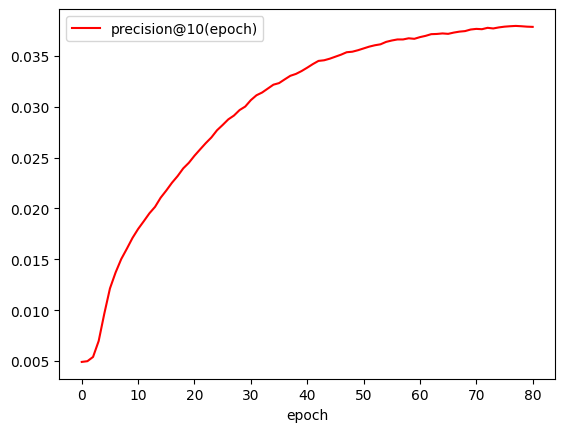

In [35]:
# TODO 1.4: Plot learning curve precision@k(epoch)
figure, ax = pl.subplots()

ax.plot(list(range(len(precisions_at))), precisions_at, "r", label="precision@10(epoch)")

ax.set_xlabel("epoch")
ax.legend()

pass

## Save track embeddings

In [36]:
BOTIFY_DATA_DIR = "/Users/n.anokhin/Projects/recsys-course/botify/data/"

In [37]:
biases, embeddings = model.get_item_representations()

In [38]:
model.item_biases *= 0.0

In [39]:
track_meta = pd.read_json(BOTIFY_DATA_DIR + "tracks.json", lines=True)
track_meta["dataset_index"] = track_meta["track"].map(lambda t: dataset.mapping()[2].get(t))

In [40]:
dataset_tracks = track_meta[pd.notnull(track_meta["dataset_index"])].sort_values("dataset_index")

In [41]:
writer = tb.SummaryWriter(comment='msd_ligtfm_embeddings', log_dir=DATA_DIR + "tb")
writer.add_embedding(embeddings, metadata=list(dataset_tracks[["artist", "title"]].itertuples(index=False, name=None)), tag="lightfm", metadata_header=["artist", "title"])
writer.close()

## Compute top recommendations

In [42]:
tracks = dataset_tracks["track"].values
users = [user for user, index in sorted(dataset.mapping()[0].items(), key=lambda kv: kv[1])]

In [43]:
with open(BOTIFY_DATA_DIR + "recommendations_lfm.json", "w") as rf:
    for user_index in tqdm.tqdm(range(dataset.user_features_shape()[0])):
        predictions = model.predict(user_index, np.arange(dataset.item_features_shape()[0]), num_threads=30)
        top = tracks[np.argsort(predictions)[-30:]]
        recommendation = {
            "user": int(users[user_index]),
            "tracks": [int(x) for x in top]
        }
        rf.write(json.dumps(recommendation) + "\n")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9756/9756 [00:10<00:00, 944.04it/s]
